# Notebook 2: Generating Training Data

This notebook shows how to generate a dataset of Gillespie SSA trajectories for training the neural surrogate.

## What this covers

1. **Interpolation onto a regular time grid** — SSA produces events at irregular times; training requires a uniform grid.
2. **M trajectories per dataset item** — each item stores M independent SSA runs for the same (CRN, initial state) pair, enabling the variance-matching loss.
3. **Dataset construction** — wrapping trajectory bundles in `CRNTrajectoryDataset`.
4. **Collation** — padding mixed-size CRNs for batching.
5. **Data inspection** — visualising trajectory mean, variance, and statistics.

## Why M trajectories per item?

The `VarianceMatchingLoss` compares `Var_pred[X(t)]` against `Var_true[X(t)]`. Computing an empirical variance requires at least M ≥ 2 trajectories. With M = 1 the variance is undefined and G_θ (the diffusion network) receives no gradient signal — it cannot learn to produce stochastic trajectories.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

## 1. Zero-Order Hold Interpolation onto a Regular Time Grid

The SSA produces events at exponentially distributed, irregular inter-event times.
For training we interpolate onto a fixed grid using **zero-order hold** (piecewise constant),
which is the correct interpolation for a jump process.

Raw:     70 events at irregular times
Gridded: torch.Size([50, 1]) on uniform grid of 50 points


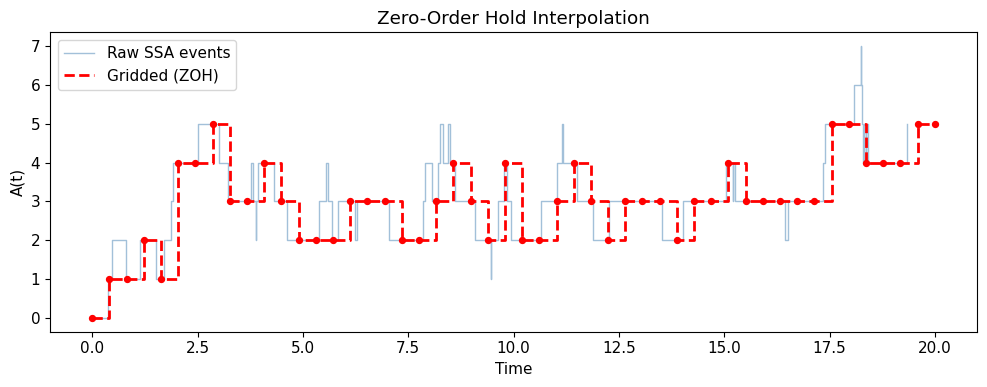

In [2]:
from crn_surrogate.crn.examples import birth_death
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

crn = birth_death(k_birth=2.0, k_death=0.5)
ssa = GillespieSSA()

raw_traj = ssa.simulate(
    stoichiometry=crn.stoichiometry_matrix,
    propensity_fn=crn.evaluate_propensities,
    initial_state=torch.tensor([0.0]),
    t_max=20.0,
)

T = 50
time_grid = torch.linspace(0.0, 20.0, T)
gridded = interpolate_to_grid(raw_traj.times, raw_traj.states, time_grid)

print(f"Raw:     {raw_traj.n_steps} events at irregular times")
print(f"Gridded: {gridded.shape} on uniform grid of {T} points")

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(raw_traj.times.numpy(), raw_traj.states[:, 0].numpy(),
        where='post', color='steelblue', alpha=0.5, linewidth=1.0, label='Raw SSA events')
ax.step(time_grid.numpy(), gridded[:, 0].numpy(),
        where='post', color='red', linewidth=2, linestyle='--', label='Gridded (ZOH)')
ax.scatter(time_grid.numpy(), gridded[:, 0].numpy(), color='red', s=18, zorder=5)
ax.set_xlabel('Time'); ax.set_ylabel('A(t)')
ax.set_title('Zero-Order Hold Interpolation'); ax.legend()
plt.tight_layout(); plt.show()

## 2. Building Dataset Items with M Trajectories

Each `TrajectoryItem` now stores `trajectories: Tensor` of shape `(M, T, n_species)` — 
M independent SSA runs for the same (CRN, initial state) pair.

The `TrainingConfig.n_ssa_samples` field controls M. For this notebook we use M=16 (smaller than the default 32 for speed).

In [3]:
from crn_surrogate.crn.examples import lotka_volterra, schlogl
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem

T_MAX = 20.0
N_GRID = 50
M = 16   # SSA trajectories per item (use 32 for real training)
time_grid = torch.linspace(0.0, T_MAX, N_GRID)

crn_configs = [
    (birth_death(k_birth=2.0, k_death=0.5), torch.tensor([0.0]),        'Birth-Death'),
    (birth_death(k_birth=5.0, k_death=1.0), torch.tensor([3.0]),        'Birth-Death (fast)'),
    (lotka_volterra(),                       torch.tensor([80.0, 30.0]), 'Lotka-Volterra'),
    (schlogl(),                              torch.tensor([30.0]),       'Schlögl'),
]

N_ITEMS_PER_CRN = 10   # dataset items per CRN type

items = []
for crn_def, init, name in crn_configs:
    crn_repr = crn_to_tensor_repr(crn_def)
    for _ in range(N_ITEMS_PER_CRN):
        # Run M independent SSA trajectories for this (CRN, init) pair
        multi = torch.stack([
            interpolate_to_grid(
                ssa.simulate(
                    stoichiometry=crn_def.stoichiometry_matrix,
                    propensity_fn=crn_def.evaluate_propensities,
                    initial_state=init.clone(),
                    t_max=T_MAX,
                ).times,
                ssa.simulate(
                    stoichiometry=crn_def.stoichiometry_matrix,
                    propensity_fn=crn_def.evaluate_propensities,
                    initial_state=init.clone(),
                    t_max=T_MAX,
                ).states,
                time_grid,
            )
            for _ in range(M)
        ])  # (M, T, n_species)
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init.clone(),
            trajectories=multi,
            times=time_grid,
        ))
    print(f"  {name}: {N_ITEMS_PER_CRN} items × {M} SSA runs = {N_ITEMS_PER_CRN * M} trajectories")

dataset = CRNTrajectoryDataset(items)
print(f"\nDataset: {len(dataset)} items, each with {M} SSA trajectories")
print(f"trajectories tensor shape per item: {items[0].trajectories.shape}")

  Birth-Death: 10 items × 16 SSA runs = 160 trajectories
  Birth-Death (fast): 10 items × 16 SSA runs = 160 trajectories
  Lotka-Volterra: 10 items × 16 SSA runs = 160 trajectories
  Schlögl: 10 items × 16 SSA runs = 160 trajectories

Dataset: 40 items, each with 16 SSA trajectories
trajectories tensor shape per item: torch.Size([16, 50, 1])


## 3. Visualising Mean and Variance per CRN Type

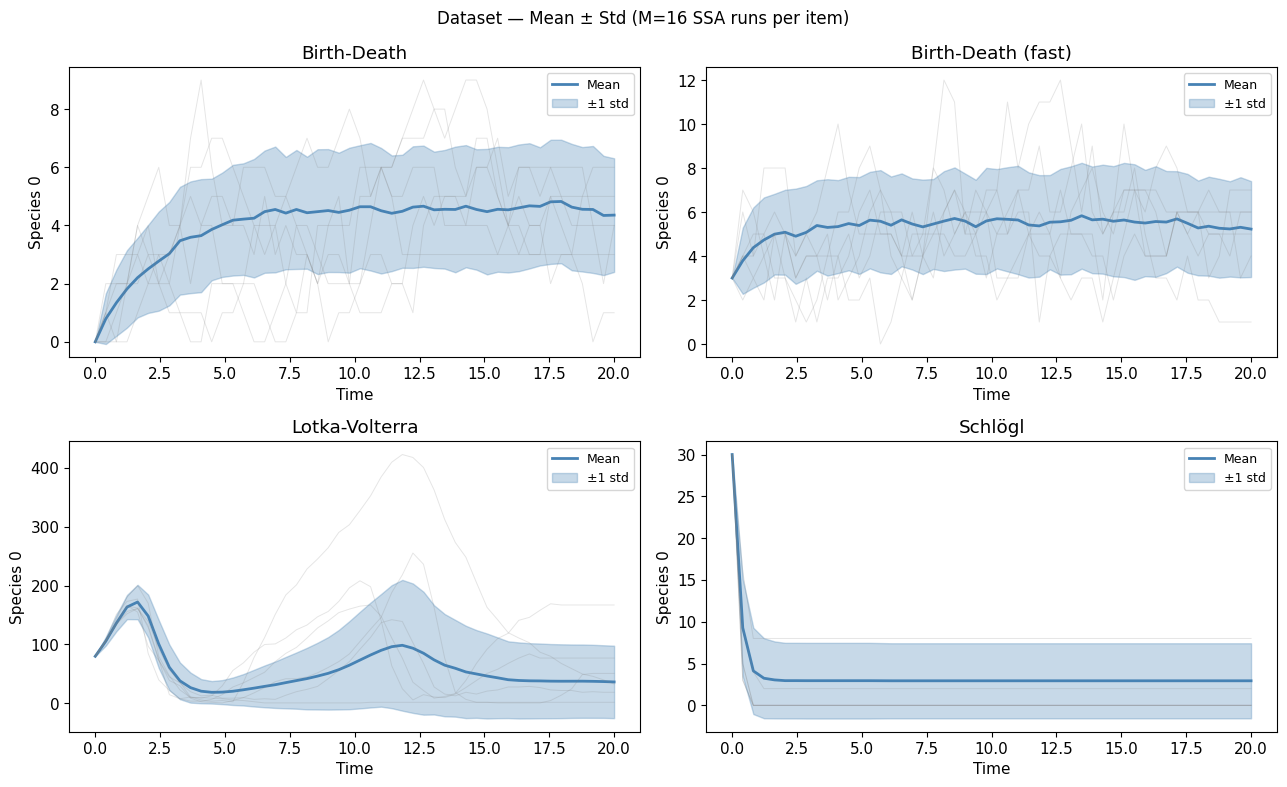

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax_idx, (crn_def, init, name) in enumerate(crn_configs):
    crn_def_repr = crn_to_tensor_repr(crn_def)
    # Gather all M*N_ITEMS_PER_CRN trajectories for this CRN type
    crn_items = [
        item for item in items
        if item.crn_repr.n_reactions == crn_def_repr.n_reactions
        and item.crn_repr.n_species == crn_def_repr.n_species
        and abs(item.crn_repr.propensity_params[0, 0].item() - crn_def_repr.propensity_params[0, 0].item()) < 0.1
    ]

    # Stack all trajectories: (N_items, M, T, n_species) → pool M dim → (N_items*M, T)
    all_trajs = torch.stack([it.trajectories[:, :, 0] for it in crn_items])  # (N, M, T)
    all_trajs = all_trajs.reshape(-1, N_GRID)  # (N*M, T)

    mean_t = all_trajs.mean(dim=0).numpy()
    std_t  = all_trajs.std(dim=0).numpy()
    t = time_grid.numpy()

    ax = axes[ax_idx]
    ax.plot(t, mean_t, color='steelblue', linewidth=2, label='Mean')
    ax.fill_between(t, mean_t - std_t, mean_t + std_t,
                    alpha=0.3, color='steelblue', label='±1 std')
    for item in crn_items[:2]:
        for m in range(min(3, M)):
            ax.plot(t, item.trajectories[m, :, 0].numpy(),
                    color='gray', alpha=0.2, linewidth=0.7)
    ax.set_title(name); ax.set_xlabel('Time'); ax.set_ylabel('Species 0')
    ax.legend(fontsize=9)

plt.suptitle(f'Dataset — Mean ± Std (M={M} SSA runs per item)', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Variance Analysis — Birth-Death

For the birth-death process the stationary distribution is Poisson(k₁/k₂),
so both the mean and the variance should converge to k₁/k₂ = 4.

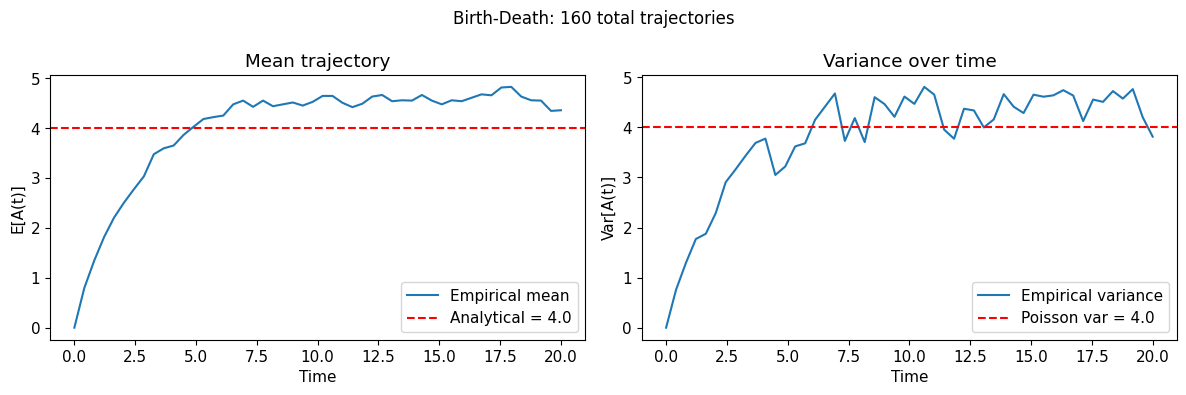

Converged mean (last 10): 4.60  (expected 4.0)
Converged var  (last 10): 4.47  (expected 4.0)


In [5]:
bd_items = [
    item for item in items
    if item.crn_repr.n_species == 1 and item.crn_repr.n_reactions == 2
    and abs(item.crn_repr.propensity_params[0, 0].item() - 2.0) < 0.1
]

# Pool all M trajectories across all items
all_bd = torch.cat([it.trajectories[:, :, 0] for it in bd_items], dim=0)  # (N*M, T)
mean_t = all_bd.mean(dim=0).numpy()
var_t  = all_bd.var(dim=0).numpy()
t = time_grid.numpy()
expected = 2.0 / 0.5  # k_birth/k_death

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, mean_t, label='Empirical mean')
axes[0].axhline(expected, color='red', linestyle='--', label=f'Analytical = {expected}')
axes[0].set_title('Mean trajectory'); axes[0].set_xlabel('Time')
axes[0].set_ylabel('E[A(t)]'); axes[0].legend()

axes[1].plot(t, var_t, label='Empirical variance')
axes[1].axhline(expected, color='red', linestyle='--', label=f'Poisson var = {expected}')
axes[1].set_title('Variance over time'); axes[1].set_xlabel('Time')
axes[1].set_ylabel('Var[A(t)]'); axes[1].legend()

plt.suptitle(f'Birth-Death: {len(all_bd)} total trajectories', fontsize=12)
plt.tight_layout(); plt.show()

print(f"Converged mean (last 10): {mean_t[-10:].mean():.2f}  (expected {expected})")
print(f"Converged var  (last 10): {var_t[-10:].mean():.2f}  (expected {expected})")

## 5. Batching with CRNCollator

The collator pads stoichiometry and trajectory tensors to the maximum sizes in the batch.
With the new M-trajectory structure, `batch["trajectories"]` has shape `(B, M, T, max_species)`.

In [6]:
from crn_surrogate.data.dataset import CRNCollator

collator = CRNCollator()
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collator)

batch = next(iter(loader))

print("Batch contents:")
for key, val in batch.items():
    print(f"  {key:25s}: shape={tuple(val.shape)}, dtype={val.dtype}")

Batch contents:
  stoichiometry            : shape=(4, 4, 1), dtype=torch.float32
  dependency_matrix        : shape=(4, 4, 1), dtype=torch.float32
  propensity_params        : shape=(4, 4, 4), dtype=torch.float32
  propensity_type_ids      : shape=(4, 4), dtype=torch.int64
  initial_states           : shape=(4, 1), dtype=torch.float32
  trajectories             : shape=(4, 16, 50, 1), dtype=torch.float32
  times                    : shape=(4, 50), dtype=torch.float32
  species_mask             : shape=(4, 1), dtype=torch.bool
  reaction_mask            : shape=(4, 4), dtype=torch.bool


In [7]:
# The trajectories tensor is now 4D: (B, M, T, max_species)
B, M_out, T_out, S_out = batch['trajectories'].shape
print(f"trajectories: B={B}, M={M_out}, T={T_out}, max_species={S_out}")
print()
print("species_mask (which species are real):")
print(batch['species_mask'])
print()
print("reaction_mask (which reactions are real):")
print(batch['reaction_mask'])

trajectories: B=4, M=16, T=50, max_species=1

species_mask (which species are real):
tensor([[True],
        [True],
        [True],
        [True]])

reaction_mask (which reactions are real):
tensor([[ True,  True,  True,  True],
        [ True,  True, False, False],
        [ True,  True, False, False],
        [ True,  True, False, False]])


## 6. Saving the Dataset to Disk

In [8]:
import os

save_dir = '../data_cache'
os.makedirs(save_dir, exist_ok=True)

serialized = [
    {
        'stoichiometry':      item.crn_repr.stoichiometry,
        'dependency_matrix':  item.crn_repr.dependency_matrix,
        'propensity_params':  item.crn_repr.propensity_params,
        'propensity_type_ids': item.crn_repr.propensity_type_ids,
        'initial_state':      item.initial_state,
        'trajectories':       item.trajectories,   # (M, T, n_species)
        'times':              item.times,
    }
    for item in items
]

save_path = os.path.join(save_dir, 'crn_trajectories.pt')
torch.save(serialized, save_path)
print(f"Saved {len(serialized)} items to {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1024:.1f} KB")
print(f"Trajectories tensor shape per item: {serialized[0]['trajectories'].shape}")

Saved 40 items to ../data_cache/crn_trajectories.pt
File size: 184.6 KB
Trajectories tensor shape per item: torch.Size([16, 50, 1])
